In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import train_test_split, learning_curve, GridSearchCV, validation_curve

In [2]:
data = pd.read_csv("dataset_exercices.csv")
data.head()

,date_inscription,age,genre,region,type_abonnement,depense_mensuelle,nb_commandes_mois_dernier,nb_retours,jours_depuis_derniere_commande,score_satisfaction,churn
0,2023-01-01,67,Femme,Maritime,Premium,35.89,2,0,163,6.1,1
1,2023-01-02,35,Homme,Maritime,Premium,40.84,3,0,134,5.9,0
2,2023-01-02,52,Femme,Kara,Premium,40.56,3,0,80,5.2,1
3,2023-01-02,68,Femme,Centrale,Premium,19.10,3,0,166,4.5,0
4,2023-01-02,30,Homme,Centrale,Standard,22.39,0,2,157,5.6,0


In [3]:
data.shape # nombres de lignes er de colonnes

(2000, 11)

In [4]:
data.describe().round(2) #Les statistiquses descriptives des donnness

,age,depense_mensuelle,nb_commandes_mois_dernier,nb_retours,jours_depuis_derniere_commande,score_satisfaction,churn
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,43.62,38.11,3.16,0.27,92.24,5.86,0.13
std,14.94,18.47,1.83,0.52,51.60,1.37,0.34
min,18.00,2.00,0.00,0.00,0.00,1.50,0.00
25%,30.00,25.53,2.00,0.00,49.00,4.90,0.00
50%,43.00,37.13,3.00,0.00,93.00,5.80,0.00
75%,57.00,50.06,4.00,0.00,138.00,6.80,0.00
max,69.00,102.10,10.00,3.00,179.00,10.00,1.00


- Analyse et imputation des donnes [correction des donnees sales]

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   date_inscription                2000 non-null   str    
 1   age                             2000 non-null   int64  
 2   genre                           2000 non-null   str    
 3   region                          2000 non-null   str    
 4   type_abonnement                 2000 non-null   str    
 5   depense_mensuelle               2000 non-null   float64
 6   nb_commandes_mois_dernier       2000 non-null   int64  
 7   nb_retours                      2000 non-null   int64  
 8   jours_depuis_derniere_commande  2000 non-null   int64  
 9   score_satisfaction              2000 non-null   float64
 10  churn                           2000 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 229.8 KB


In [6]:
# On remarque bien avec infos que nos donnees ne contiennent pas de valeurs manquantes 
#  En plus le type de la variable est un str or cela devra etre un datetime .donc a corriger

In [7]:
# confirmation  des valeurs manquantes
data.isnull().mean()*100 # Pourcentages des valeurs manquantes dans chaque variable

date_inscription                  0.0
age                               0.0
genre                             0.0
region                            0.0
type_abonnement                   0.0
depense_mensuelle                 0.0
nb_commandes_mois_dernier         0.0
nb_retours                        0.0
jours_depuis_derniere_commande    0.0
score_satisfaction                0.0
churn                             0.0
dtype: float64

- Aucune donne manquante donc la fonction infos a comfirmer mon analyse sur ce sujet donc , maintenant je vais me concentrer sur la correction du type de donnee de la variable date_inscription

In [8]:
data["date_inscription"] = pd.to_datetime(data["date_inscription"]) # Correction  du type de donne

In [9]:
data.info() # Explorons voir si la correction a fonctionner

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date_inscription                2000 non-null   datetime64[us]
 1   age                             2000 non-null   int64         
 2   genre                           2000 non-null   str           
 3   region                          2000 non-null   str           
 4   type_abonnement                 2000 non-null   str           
 5   depense_mensuelle               2000 non-null   float64       
 6   nb_commandes_mois_dernier       2000 non-null   int64         
 7   nb_retours                      2000 non-null   int64         
 8   jours_depuis_derniere_commande  2000 non-null   int64         
 9   score_satisfaction              2000 non-null   float64       
 10  churn                           2000 non-null   int64         
dtypes: datetime64[u

Carree la correction a belle et bien fonctionner, donc je passe a la visualisation avec sourires holala que j'aime visualiser 

- Distribution des ages des clients et verification des valeur aberantes

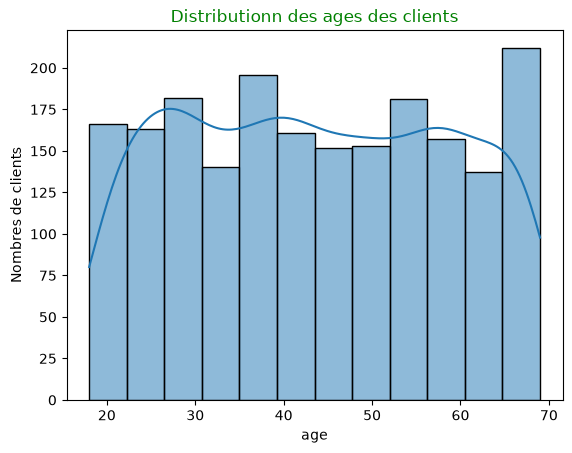

In [10]:
sns.histplot(data = data, x = "age", kde = True)
plt.title("Distributionn des ages des clients" ,c ="green" )
plt.ylabel("Nombres de clients")
plt.show()

Text(0.5, 1.0, 'Distrubution des ages selon les regions')

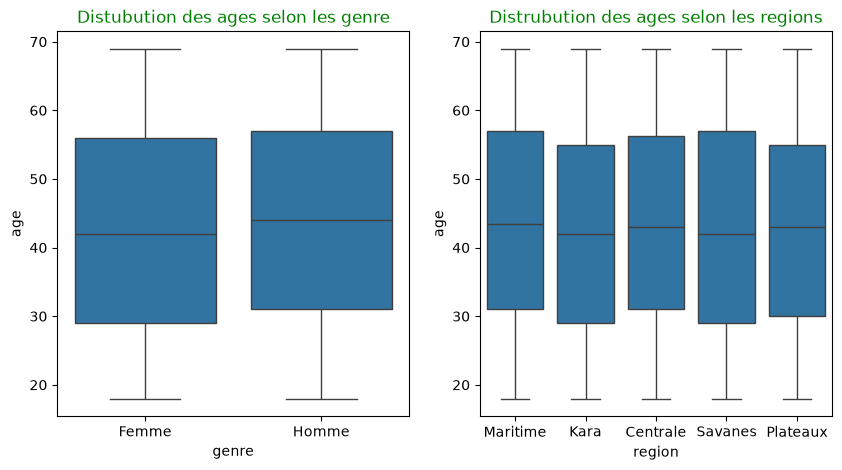

In [11]:
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plt.title("Distubution des ages selon les genre", c= "green")
sns.boxplot(data = data, x= "genre",y = "age")
plt.subplot(1, 2, 2)
sns.boxplot(data = data, x = "region", y = "age")
plt.title("Distrubution des ages selon les regions",c = "green")

Sur nos donnnes de la distrubutions des ages , il n'existe pas d'outliers,je reviendrai bien lire le graphe pour essaiyer de voir les ages min , max selon le genre ou la region mais bon comme ce fichier est dedier pour l'apprentissages des modeles , alors j'essaiyaits juste de m'amiuser un peut donc voila je suis tres impatients d'attaquer ces models, moi seul a 0 heurs 37 minutes du mation ha , hummm !! 

- Distrubution des depenses mensuelles

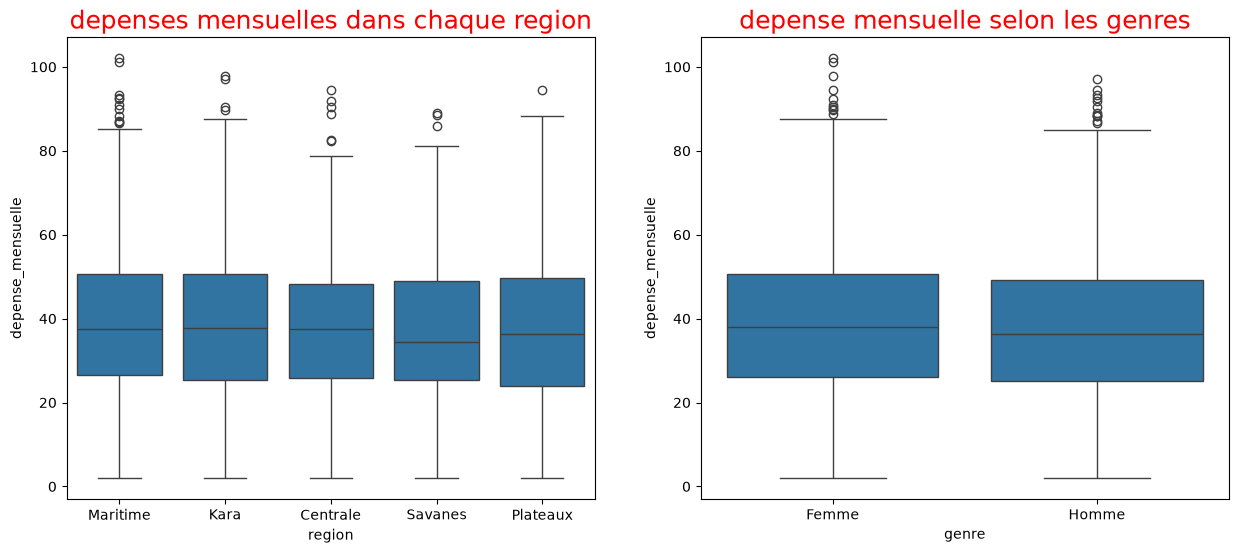

In [12]:
plt.figure(figsize=(15, 6))
plt.subplot(1,2,1)
plt.title("depenses mensuelles dans chaque region", c = "red" ,size = 18)
sns.boxplot(data = data, y = "depense_mensuelle",x = "region")
plt.subplot(1,2,2)
plt.title("depense mensuelle selon les genres", c = "red" ,size = 18)
sns.boxplot(data = data, y = "depense_mensuelle",x = "genre")
plt.show()

Poitate que des donnes aberantes dans la variables de de depnse mensuelle es charger

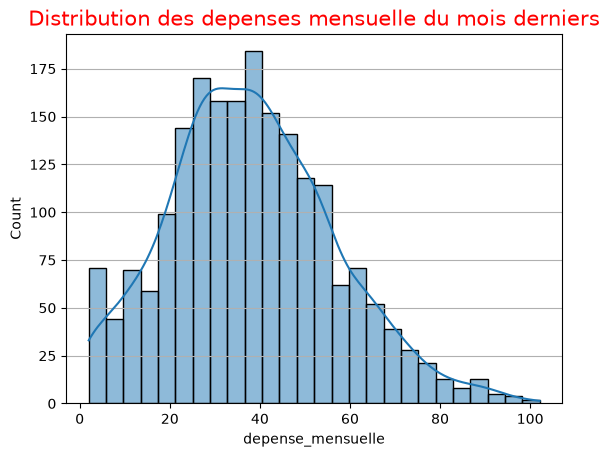

In [13]:
sns.histplot(data = data , x = "depense_mensuelle", kde = True)
plt.title("Distribution des depenses mensuelle du mois derniers", c = "red", size = 15)
plt.grid(axis = "y")
plt.savefig("depense_mesuelle.png", dpi =150)
plt.show()

-  `Verifions les niveau des variables categorielle`

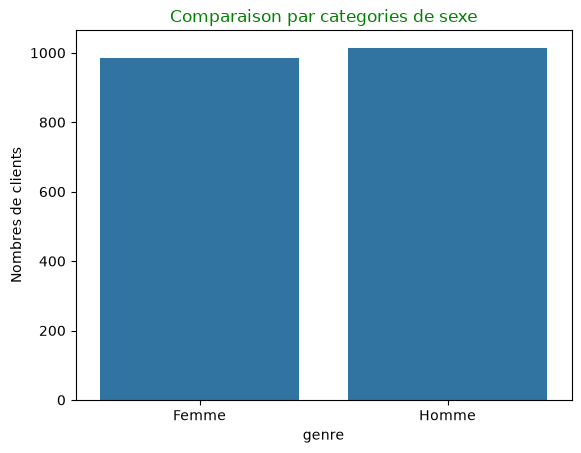

In [14]:
ax = sns.countplot(data = data, x = "genre")
plt.title("Comparaison par categories de sexe",  c= "green")
plt.ylabel("Nombres de clients")
# for container in ax.containers:
#     for  objet in container:
#         taille = objet.get_heigt()
#         if taille<0:
#             x = 
plt.show()

il y'a plus , de clients de genre masculin que feminin d'apres l'analyse 

- `Comaparaison des categories de la variables region`

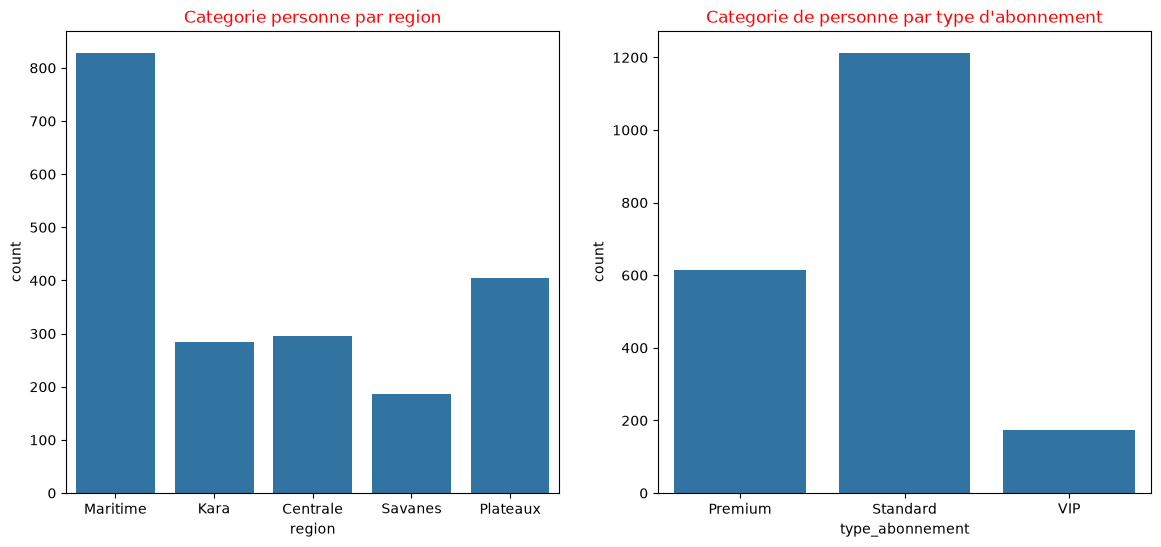

In [15]:
plt.figure(figsize = (14,6))
plt.subplot(1,2,1)
plt.title("Categorie personne par region", c = "red")
sns.countplot(data = data, x = "region")
plt.subplot(1,2,2)
plt.title("Categorie de personne par type d'abonnement",c = "red")
sns.countplot(data = data, x = "type_abonnement")
plt.show()

---

- Verification des relation entre les differentes variadble de nos jeux de donnees

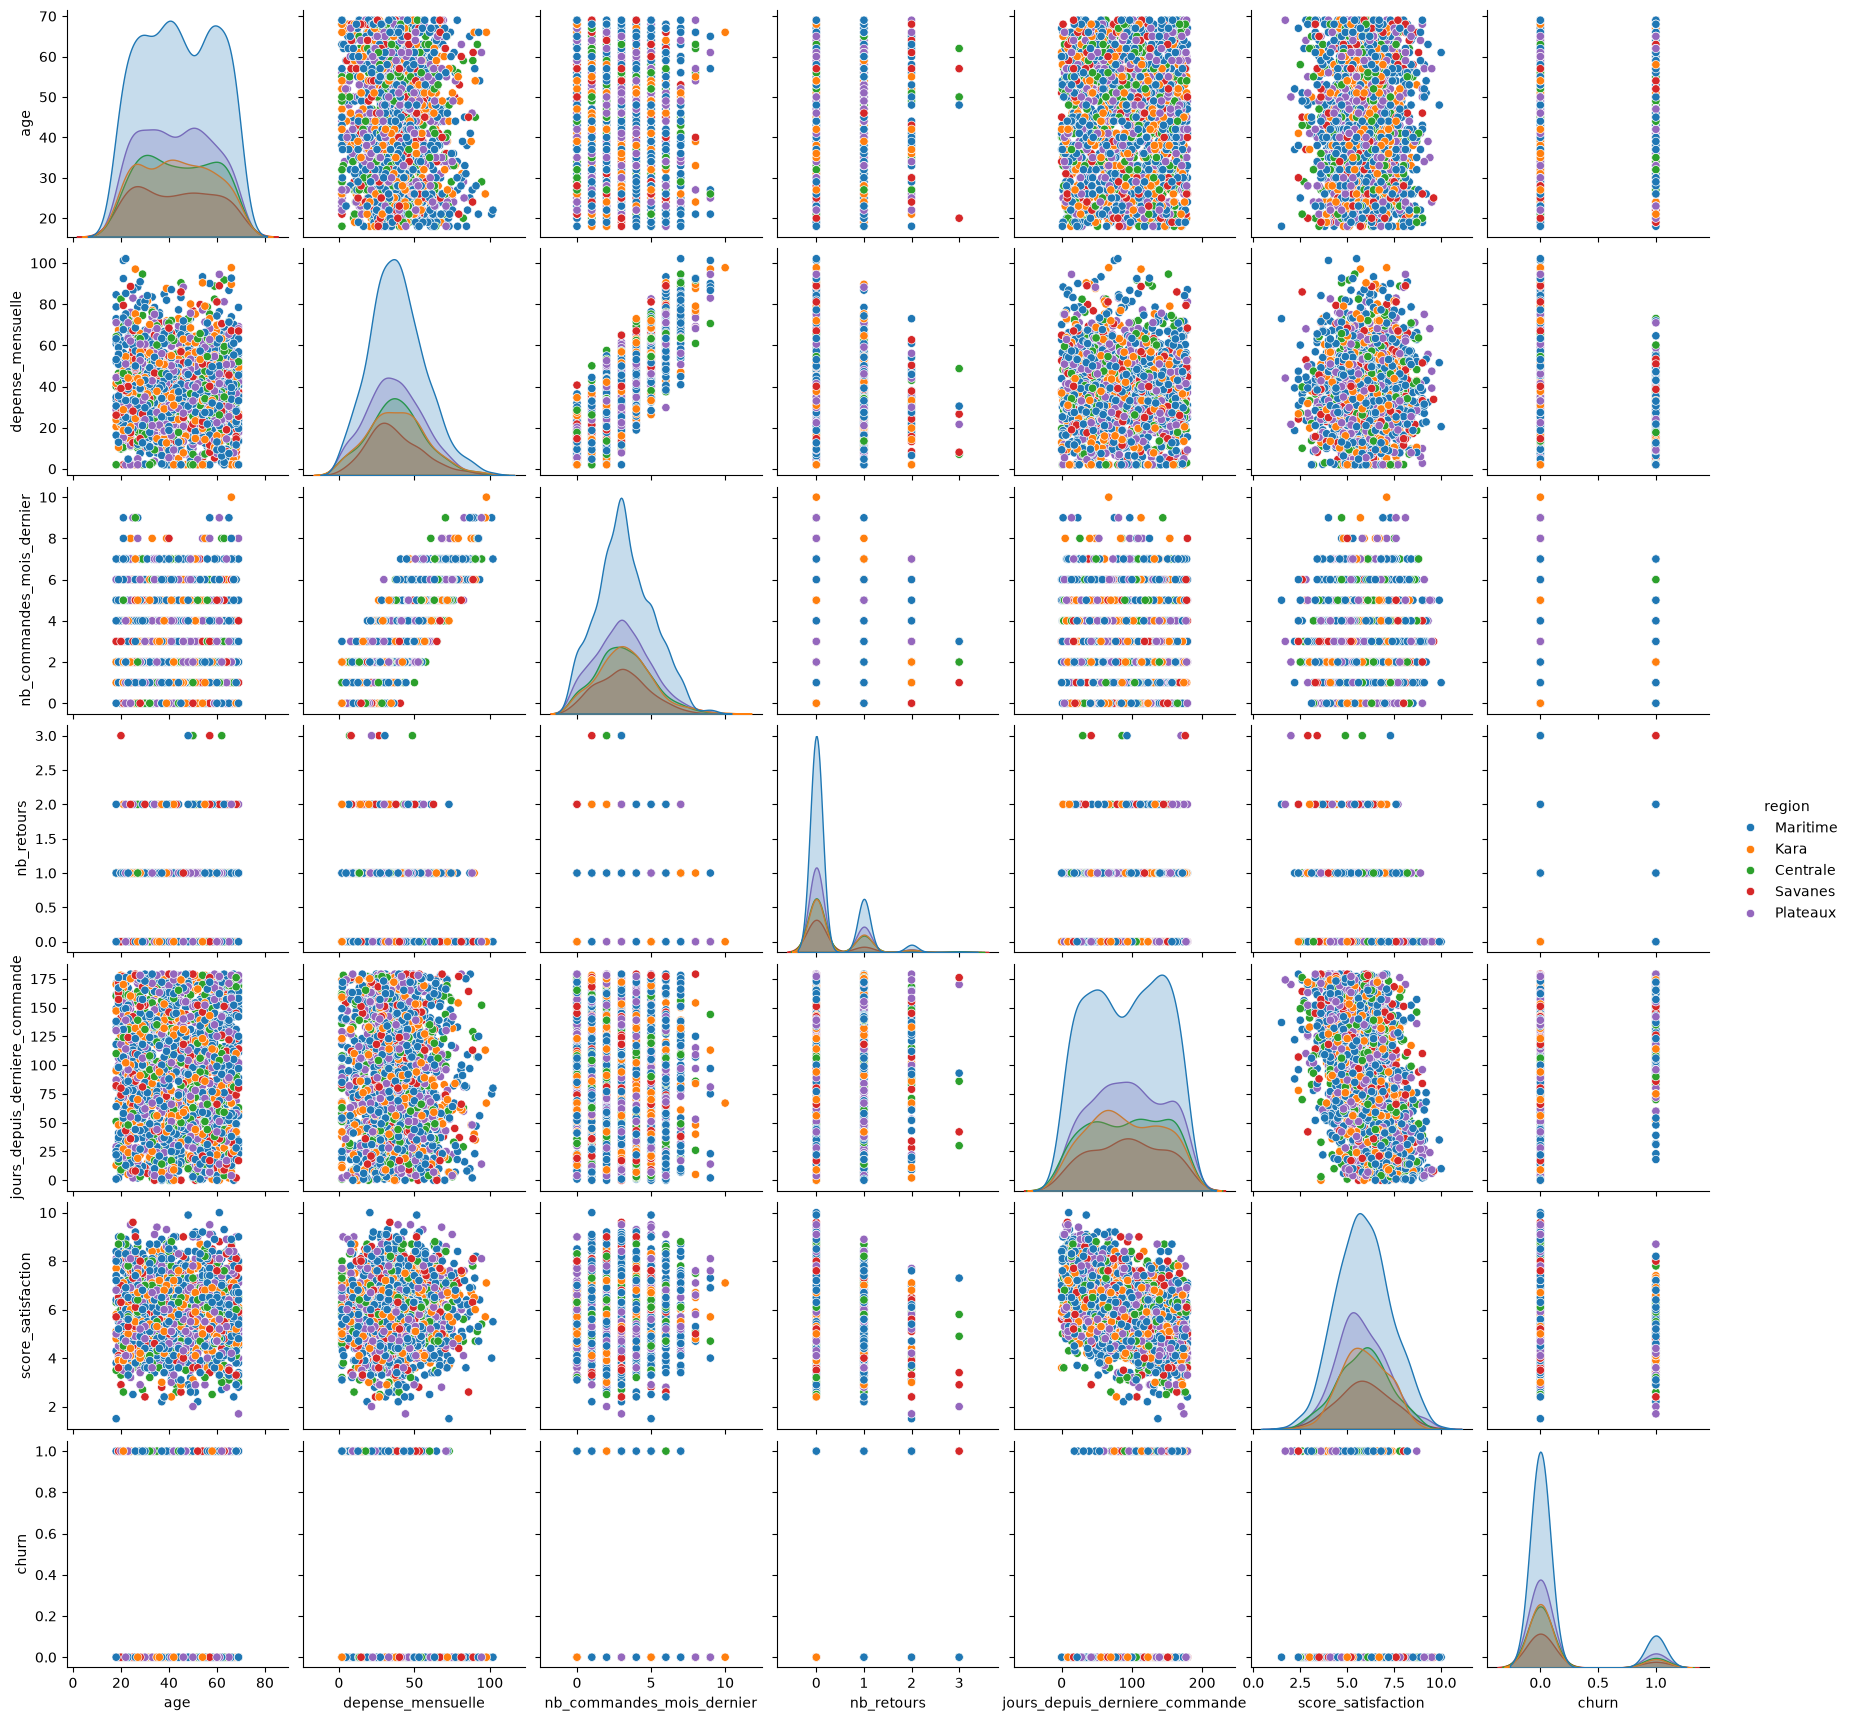

In [16]:
sns.pairplot(data, hue = "region")
plt.show()

- Correlation entre les differntes varibles numerique

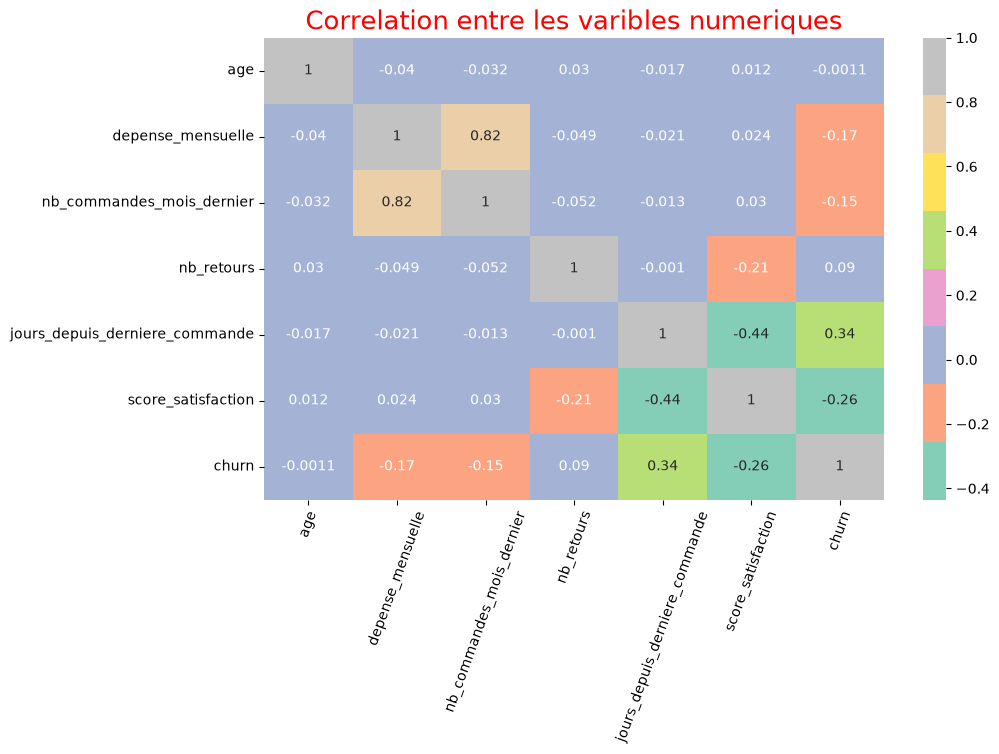

In [17]:
plt.figure(figsize= (10, 6))
sns.heatmap(data.corr(numeric_only= True),annot = True, alpha= 0.8, cmap = "Set2")
plt.title("Correlation entre les varibles numeriques", c = "red", size = 19)
plt.xticks(rotation = 70)
plt.show()

- Analyse de la distrubution de la variable Variable churn 

<Axes: title={'center': 'Distribution de la variable churn(histogramme)'}, xlabel='churn', ylabel='count'>

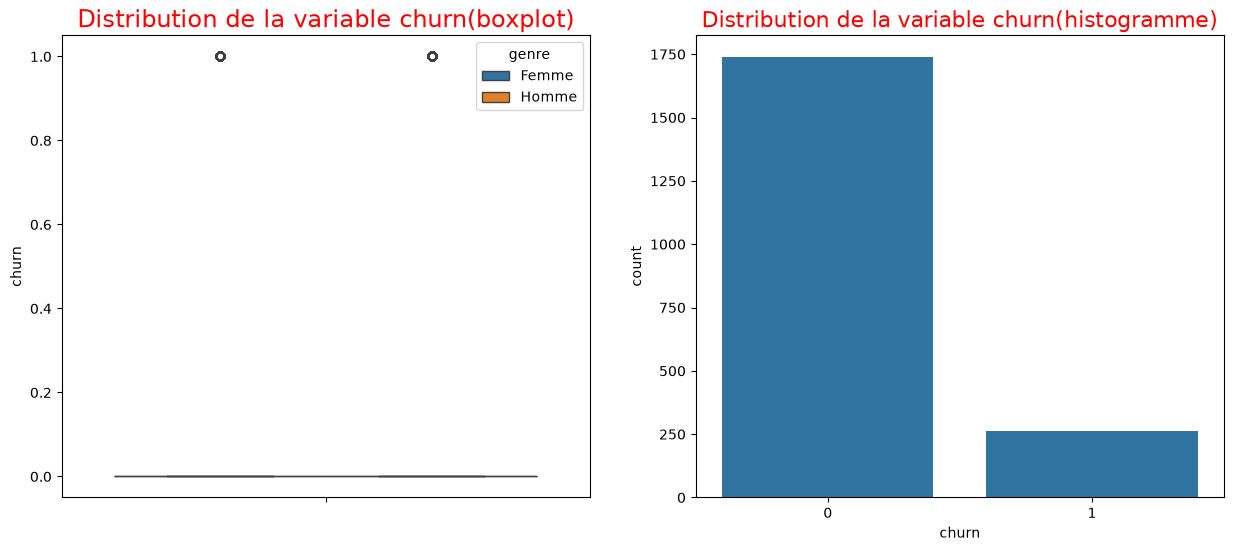

In [18]:
plt.figure(figsize = (15, 6))
plt.subplot(1,2,1)
sns.boxplot(data = data, y = "churn", hue = "genre")
plt.title("Distribution de la variable churn(boxplot)", c = "red", size = 17)
plt.subplot(1,2,2)
plt.title("Distribution de la variable churn(histogramme)", c = "red", size = 16)
sns.countplot(data = data, x = "churn")

- Evolution dans le temp

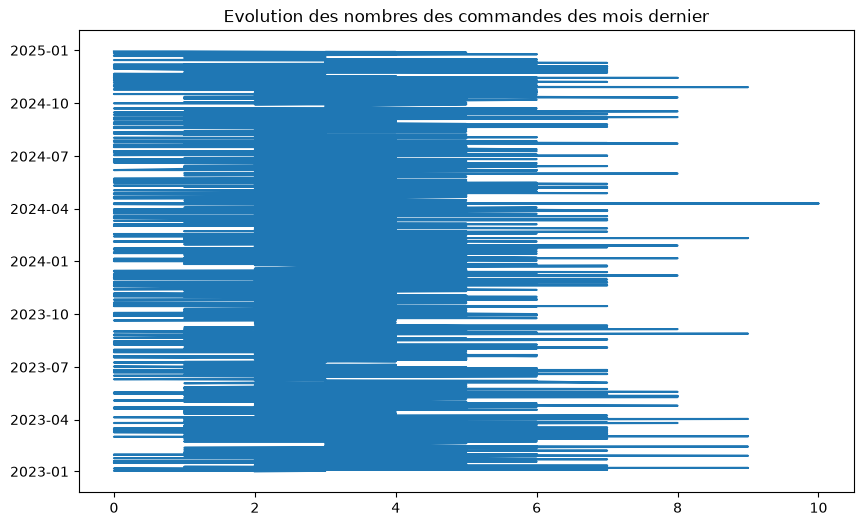

In [19]:
plt.figure(figsize = (10,6))
plt.title("Evolution des nombres des commandes des mois dernier")
plt.plot(data["nb_commandes_mois_dernier"], data["date_inscription"])
plt.show()


<h2><span style = "color : red">Modele 1 :</span><span style = "color : green">Arbres de decision</span></h2> 

- <p style = "background : blue; color : white"
    >
    Mini-projet : Arbre de decision
</p>

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, validation_curve, GridSearchCV, learning_curve
from sklearn.tree import DecisionTreeRegressor

In [21]:
data.head()

,date_inscription,age,genre,region,type_abonnement,depense_mensuelle,nb_commandes_mois_dernier,nb_retours,jours_depuis_derniere_commande,score_satisfaction,churn
0,2023-01-01,67,Femme,Maritime,Premium,35.89,2,0,163,6.1,1
1,2023-01-02,35,Homme,Maritime,Premium,40.84,3,0,134,5.9,0
2,2023-01-02,52,Femme,Kara,Premium,40.56,3,0,80,5.2,1
3,2023-01-02,68,Femme,Centrale,Premium,19.10,3,0,166,4.5,0
4,2023-01-02,30,Homme,Centrale,Standard,22.39,0,2,157,5.6,0


Apres apres avoir  apris le cours theorique dans le pdf maintenant je me concenctre sur le projet avec l'obejetif d'aprendre le  modele de l'arbres de decision (DecisionTreeClassifier)

<p style = "color : red">1. Predire churn avec un DecisionTreeClassifier. Que vaut l’accuracy avec
max_depth=2 puis max_depth=None ? Que se passe-t-il sur le score en train vs en
test dans chaque cas ? Expliquez le lien avec l’over tting.</p>


In [22]:
# Churn signifie le taux de perte de la clientelle

- Identifions les variables qui sont lie au churn et et essayons d'identifier si on peut predire le churn

<Axes: >

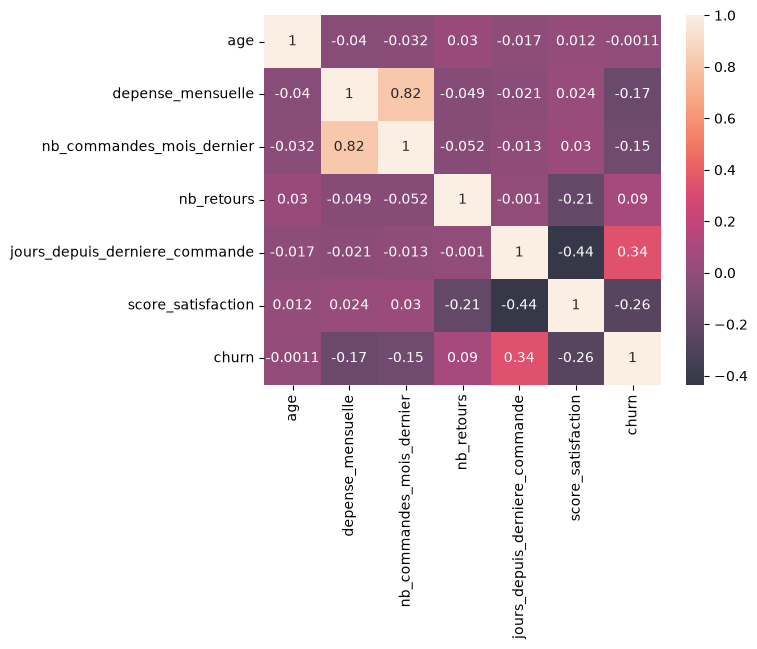

In [23]:
sns.heatmap(data.corr(numeric_only= True),annot = True, alpha= 0.8)

Bien d'apres le heatmap , ma variable predictive (churn) a une correlation assez forte avec les variables : 
- score_satisfaction       : -0.26
- depense_mensuelle        : -0.17
- nb_commande_mois_dernier : -0.15
- jour_depuis_derniere_commande : 0.34

Pour ce mini projet je vais me baser de ces variable la pour la prediction mais bon je dans la suite je pense retirer certains variables pour voir la perf du nouveau modele

In [24]:
X = data[["score_satisfaction", "depense_mensuelle", "nb_commandes_mois_dernier", "jours_depuis_derniere_commande"]]
y = data["churn"]

In [25]:
y  # Notre variable churn permet de savoir si un le client achete ou abandonne (1 - vrai et 0 -Fauz)

0       1
1       0
2       1
3       0
4       0
       ..
1995    0
1996    0
1997    0
1998    1
1999    0
Name: churn, Length: 2000, dtype: int64

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state= 42,test_size= 0.2, stratify= y) # Separation des donnees
#stratify = y permet de conserver les portions des classes
print(f"Donnees de l'enntrainement : {X_train.shape}")
print(f"Donnees de l'evaluation    : {X_test.shape}")

Donnees de l'enntrainement : (1600, 4)
Donnees de l'evaluation    : (400, 4)


- Modele avec ***max_depth = 2***

In [27]:
modele_arbre_02 = DecisionTreeClassifier(max_depth= 2 , random_state= 42 ) # avec max_depth = 2
modele_arbre_00 = DecisionTreeClassifier(max_depth= None, random_state=42) # Avec max_depth = None
modele_arbre = DecisionTreeClassifier(random_state=42) # Avec max_depth par defaut


# Entrainement sur les donnes de l;entrainement
modele_arbre.fit(X_train, y_train)
modele_arbre_00.fit(X_train, y_train)
modele_arbre_02.fit(X_train, y_train)

 # Sur les donnes de l'entrainement 
score_train_02 = modele_arbre_02.score(X_train, y_train)
score_train_00= modele_arbre_00.score(X_train, y_train)
r = score_train= modele_arbre_00.score(X_train, y_train)
print(f"Score a l;entrainement du modele avec max_depth = 2   : {round(score_train_02, 4)*100} %")
print(f"Score a l;entrainement du modele avec max_depth = None   : {round(score_train_00, 4)*100} %")
print(f"Score a l;entrainement du modele avec max_depth a defaut   : {round(r, 2)*100} %")

Score a l;entrainement du modele avec max_depth = 2   : 86.88 %
Score a l;entrainement du modele avec max_depth = None   : 100.0 %
Score a l;entrainement du modele avec max_depth a defaut   : 100.0 %


Le modele a l'aire en forme hein  j'espere que je ne vais pas croiser un probleme de overfiting hein ok, bon je vais tester ces donnes sur ceux de la validation voir, apres je vais conclure avec les metrique et voir la performance et amelioration 
- **Pour max_depth** = *None* :on a ***100 %*** comme score
- **Pour max_depth** = *2* , on a ***86.88 %*** comme score de prediction

In [28]:
# max_depth = None
val_score_00 = cross_val_score(modele_arbre_00, X_train, y_train , cv = 5)
val_score_00 = round(val_score_00.mean(), 4)*100

# max_depth = 2
val_score_02 = cross_val_score(modele_arbre_02, X_train, y_train , cv = 5)
val_score_02 = round(val_score_02.mean(), 4)*100
print(f"Le score sur les donnees de la validation (max_depth = None) : {val_score_00} %")
print(f"Le score sur les donnees de la validation (max_depth = 2) : {val_score_02} %")

Le score sur les donnees de la validation (max_depth = None) : 81.88 %
Le score sur les donnees de la validation (max_depth = 2) : 86.37 %


- Bien pour la remarque avec le changemeent de la profondeur du model , on peu bien remarque que le modele_00 , est meilleur a l'entrainment avec 100% et a chuter avec les donnes de la validation de 100% a 81.88% pour comprendre bien si le modele est regler sur none alors sur les donnes de l'entrainement le model buche seulememt les donnes, ils ne les aprend pas correctement .
- Contrairement au modele_02 avec max_depth = 2 , le modele a eu un score de 86.88% sur les donnes de le'entrainement contre 86.37 % a l'evaluation.
En definitive je choisiraie le modele 2 car elle est la meilleur pas de overfiting , c;est moyen

In [29]:
# Je vais tracer le graphe de de la validation du modeles avec leur donnees d'enttainement en testeant toutes les poarametre de depth

In [30]:
iteration  =  np.arange(1, 50,1)
train_score, val_score = validation_curve(modele_arbre,
    X_train ,
    y_train, 
    param_name = "max_depth", 
    param_range =iteration, cv = 5,
    #scoring = "recall" # apparament ce parametre est important pour lA CYBERSECURITE
)

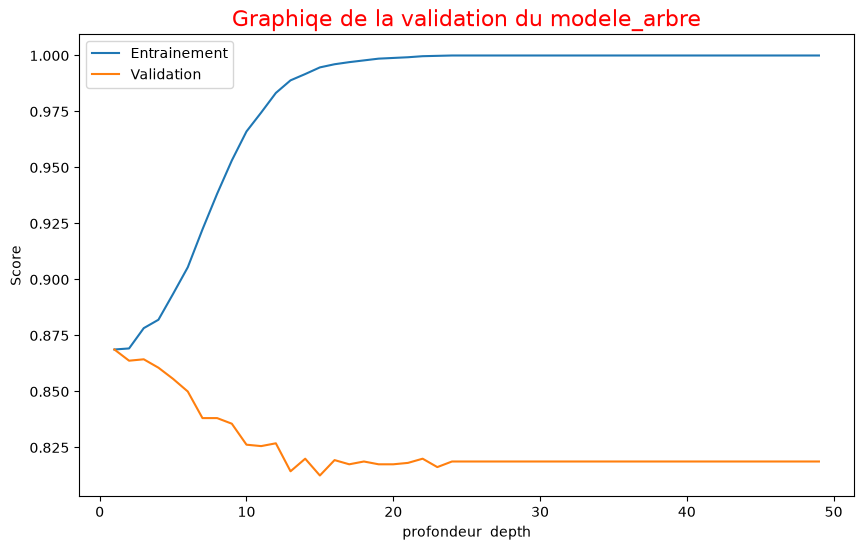

In [31]:
plt.figure(figsize = (10, 6))
plt.title("Graphiqe de la validation du modele_arbre", c = "red", size = 16)
plt.plot(iteration, train_score.mean(axis = 1), label = "Entrainement")
plt.plot(iteration, val_score.mean(axis = 1), label = "Validation")
plt.xlabel("profondeur  depth")
plt.ylabel("Score")
plt.legend()

le modele est visuellement efficace car d'apres le graphe le modele a la capacite d'aprendre jusqu'a plus de 85% et limite sa performance au dessus de 80% , pour moi il y'a overfeting 

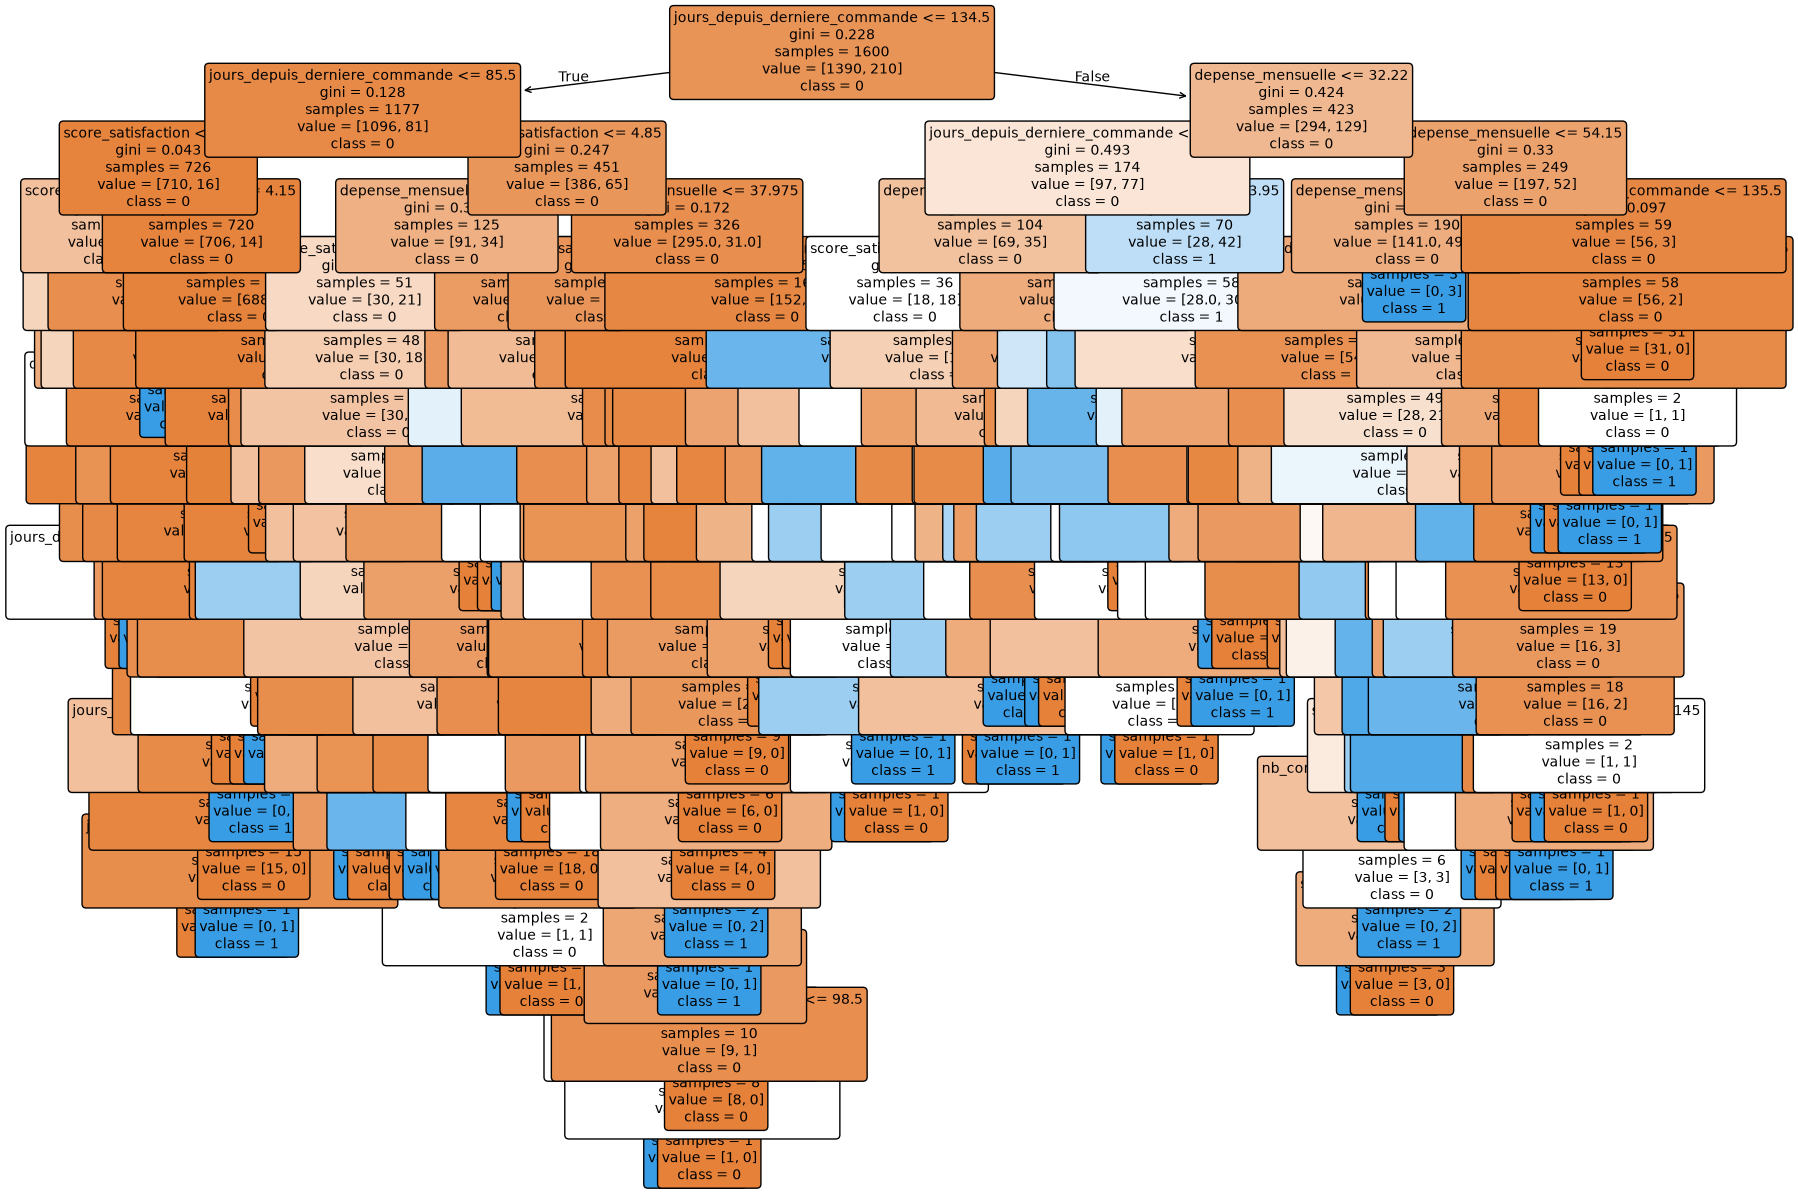

<Figure size 640x480 with 0 Axes>

In [32]:
plt.figure(figsize=(20, 15))

plot_tree(
    modele_arbre, 
    feature_names = X.columns,           # Nom des colonnes parfait
    class_names = ["0", "1"], #  nom des classe de la variable a predire 
    filled = True,
    rounded = True,
    fontsize = 10
)
plt.show()
plt.savefig("Arbre_Decision.png", dpi = 150)

- Recherche des hyper_parametres

In [33]:
parametre = {
    "max_depth"         : [2, 4,8,10,16, 20, 100, None],
    "min_samples_split" : [2,5,10],
    "min_samples_leaf"  : [1,2,4],
    "criterion"         : ["gini", "entropy"]
}

grid_f1 = GridSearchCV(
    estimator= modele_arbre,
    param_grid= parametre,
    scoring= "f1",
    n_jobs= -1,  # Rend la recherche plus rapide
    cv = 5
)


grid_f1.fit(X_train, y_train)

grid_accuracy = GridSearchCV(
    estimator= modele_arbre,
    param_grid= parametre,
    scoring= "accuracy",
    n_jobs= -1,  # Rend la recherche plus rapide
    cv = 5
)
grid_accuracy.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",Tru

Le meilleur score de notre model est de **86.75 %** sur les donnes de l'entrainement


- Bien maintenant je vais tracer le learning curve et voir si notre modele a besoin dde donnes d'apprentissage ou pas

In [34]:
meilleur_model_f1 = grid_f1.best_estimator_
meilleur_model_accuracy = grid_accuracy.best_estimator_
train_sizes, train_score_f1, val_score_f1 = learning_curve(
    meilleur_model_f1,
    X_train,
    y_train,
    train_sizes= np.linspace(0.1, 1.0, 10),
    cv = 5
)

train_sizes, train_score_accur, val_score_accur = learning_curve(
    meilleur_model_accuracy,
    X_train,
    y_train,
    train_sizes= np.linspace(0.1, 1.0, 10),
    cv = 5
)

In [35]:
train_sizes

array([ 128,  256,  384,  512,  640,  768,  896, 1024, 1152, 1280])

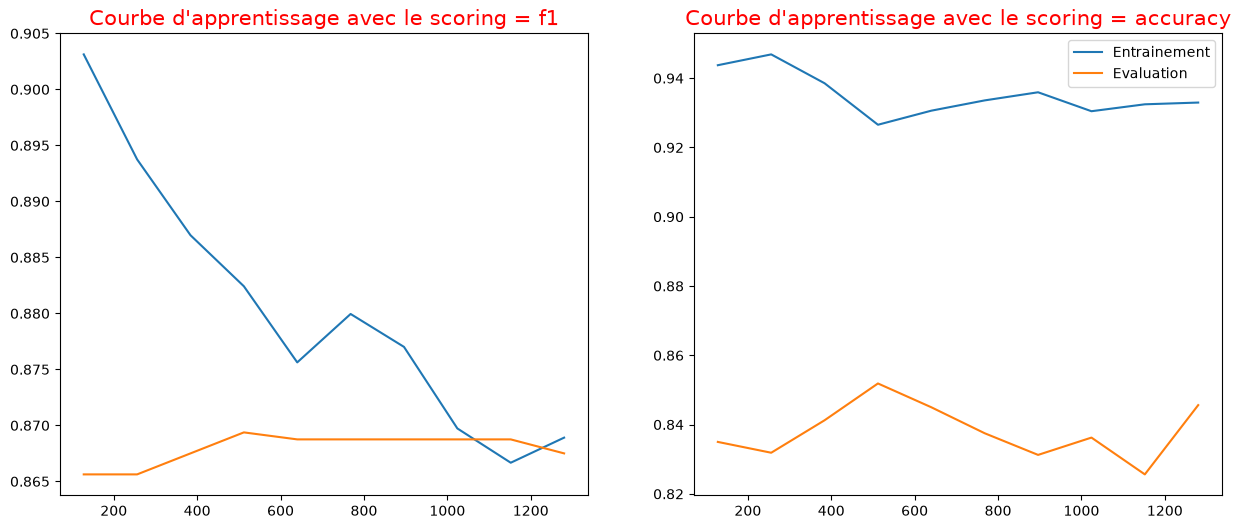

In [36]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
plt.title("Courbe d'apprentissage avec le scoring = f1", c = "red", size = 15)
plt.plot(train_sizes, train_score_accur.mean(axis = 1), label = "Entrainement")
plt.plot(train_sizes, val_score_accur.mean(axis = 1), label = "Evaluation")

plt.subplot(1,2,2)
plt.title("Courbe d'apprentissage avec le scoring = accuracy", c = "red", size  = 15)
plt.plot(train_sizes, train_score_f1.mean(axis = 1), label = "Entrainement")
plt.plot(train_sizes, val_score_f1.mean(axis = 1), label = "Evaluation")
plt.legend()

<p style = "background : blue; color :white">Analyse du graphe </p>

- La courbe d'apprentissage sur le accuracy montre un écart entre les performances d'entraînement et d'évaluation. Le modèle présente donc un certain surapprentissage, mais les performances d'évaluation restent relativement stables autour de 83–85 %. L'ajout de données ne semble pas apporter une amélioration significative dans cette configuration.

- La Learning Curve basée sur le F1-score montre que l'écart entre les performances d'entraînement et d'évaluation diminue avec l'augmentation des données. Les deux courbes convergent vers un F1 proche de 0,87, ce qui indique une bonne capacité de généralisation du modèle. 



<p style = "background : blue; color :white">Bien Analysons les performance de nos donnes sur les donnes du train tes</p>

- ***Matrice de confusion***

In [37]:
confusion_accur = confusion_matrix(y_test, grid_accuracy.predict(X_test)) # Avec accuracy 
confusion_f1 = confusion_matrix(y_test, grid_f1.predict(X_test))

print(f"Matrice  de confusion avec scoring = f1 :\n {confusion_f1}")
print(f"Matrice  de confusion avec scoring = accuracy :\n {confusion_accur}")

Matrice  de confusion avec scoring = f1 :
 [[326  21]
 [ 40  13]]
Matrice  de confusion avec scoring = accuracy :
 [[347   0]
 [ 53   0]]


<p style = "background : blue; color :white">Interpretation de la matrice de confusion</p>


- `Avec scoring = "f1"`
Le modèle prédit correctement 326 clients qui ne quittent pas et 13 clients qui quittent réellement. Il commet 21 faux positifs et 40 faux négatifs. Cela montre surtout que le modèle arrive à détecter une partie des clients en situation de churn.

- `Avec scoring = "accuracy"`:
Ici, le modèle prédit tous les clients comme ne quittant pas. Il détecte donc 0 client en churn, même s'il obtient une accuracy de 86,75 %. Cette performance est trompeuse, car la classe 0 est majoritaire.

Le choix de scoring="f1" est donc plus pertinent pour notre problème de churn. L'objectif n'est pas seulement d'avoir beaucoup de prédictions correctes, mais surtout de réussir à identifier les clients susceptibles de partir. Le F1 permet ainsi de mieux tenir compte de la capacité du modèle à détecter la classe 1.


In [38]:
accuracy_score(y_test, grid_f1.predict(X_test))

0.8475

In [39]:
accuracy_score(y_test, grid_accuracy.predict(X_test))

0.8675

In [40]:
rapport= classification_report(y_test, grid_accuracy.predict(X_test), target_names=["0", "1"], output_dict = True)

df_rapport = pd.DataFrame(rapport)
df_rapport

C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\dc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classificatio

,0,1,accuracy,macro avg,weighted avg
precision,0.86750,0.0,0.8675,0.433750,0.752556
recall,1.00000,0.0,0.8675,0.500000,0.867500
f1-score,0.92905,0.0,0.8675,0.464525,0.805950
support,347.00000,53.0,0.8675,400.000000,400.000000


<p style = "background : blue; color :white">4 -  Remplacez la cible par depense_mensuelle (regression) avec un
DecisionTreeRegressor. valuez avec le RMSE. Que remarquez-vous par
rapport la classi cation ?</p>

In [41]:
data.head()

,date_inscription,age,genre,region,type_abonnement,depense_mensuelle,nb_commandes_mois_dernier,nb_retours,jours_depuis_derniere_commande,score_satisfaction,churn
0,2023-01-01,67,Femme,Maritime,Premium,35.89,2,0,163,6.1,1
1,2023-01-02,35,Homme,Maritime,Premium,40.84,3,0,134,5.9,0
2,2023-01-02,52,Femme,Kara,Premium,40.56,3,0,80,5.2,1
3,2023-01-02,68,Femme,Centrale,Premium,19.10,3,0,166,4.5,0
4,2023-01-02,30,Homme,Centrale,Standard,22.39,0,2,157,5.6,0


<Axes: xlabel='region', ylabel='depense_mensuelle'>

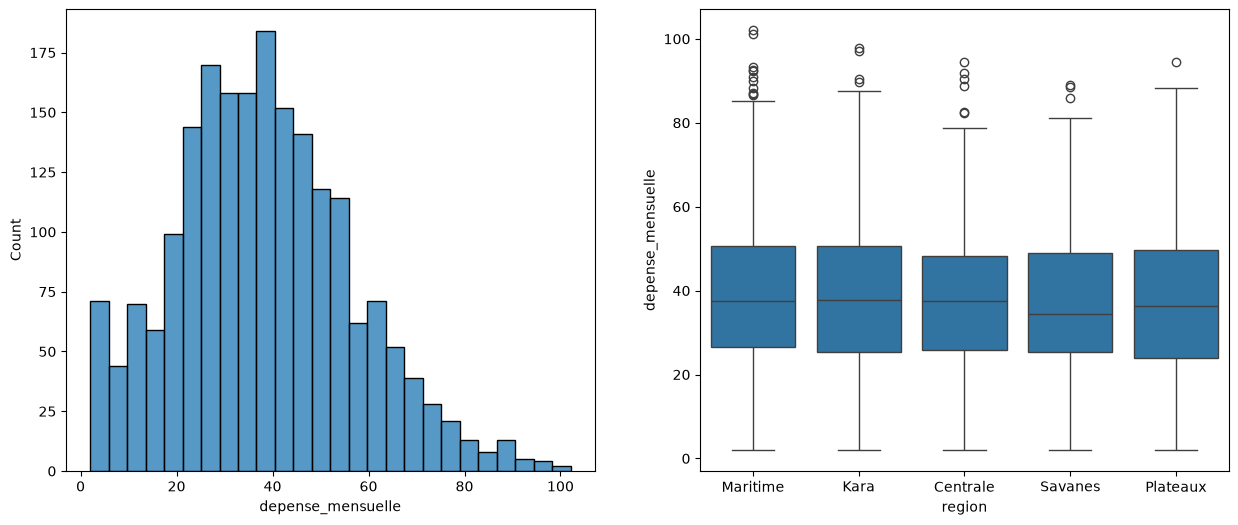

In [43]:
plt.figure(figsize= (15,6))
plt.subplot(1,2,1)
sns.histplot(data = data , x = "depense_mensuelle")
plt.subplot(1,2,2)
sns.boxplot(data = data, y = "depense_mensuelle",  x= "region")

<Axes: >

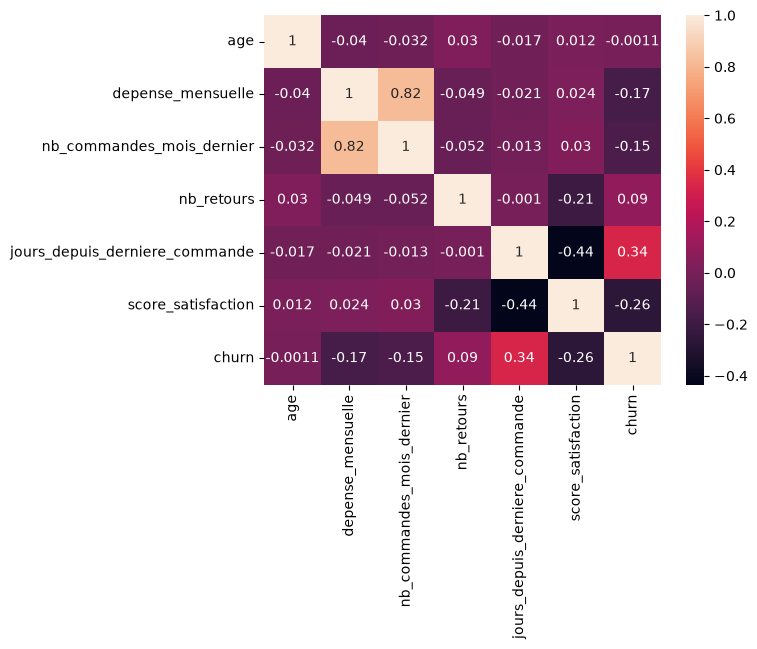

In [44]:
sns.heatmap(data.corr(numeric_only= True), annot = True)

In [55]:
X = data[["churn", "jours_depuis_derniere_commande"]]
y = data["depense_mensuelle"]

In [56]:
X = X.values
y = y.values

Text(0, 0.5, 'depense_mesuelle')

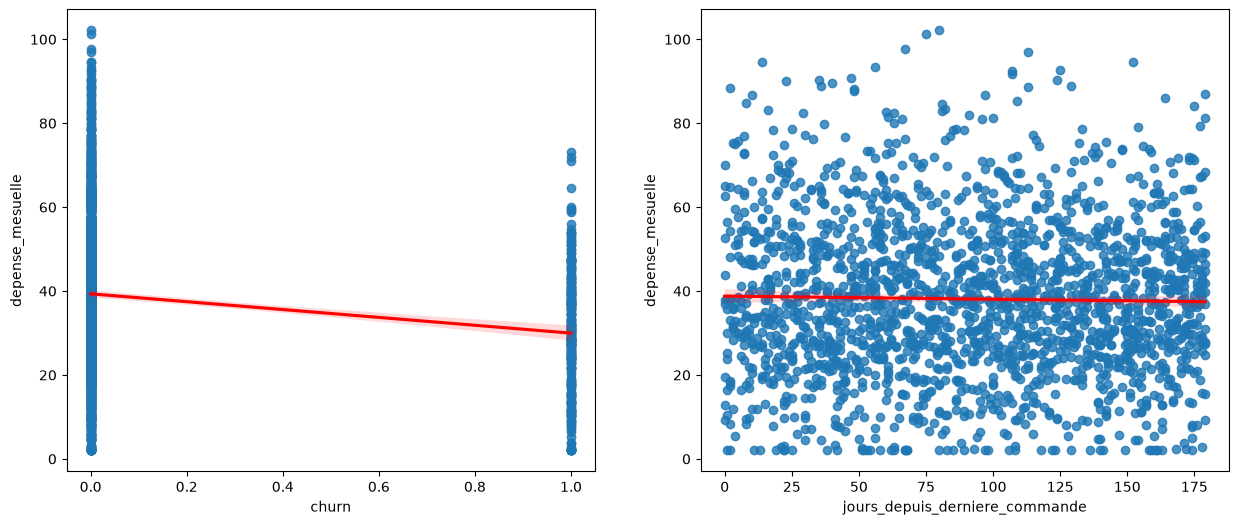

In [85]:
plt.figure(figsize= (15,6))
plt.subplot(1,2,1)
sns.regplot(data =X, x = X[:, 0], y = y, line_kws= {"color" : "red"})
plt.xlabel("churn")
plt.ylabel("depense_mesuelle")
plt.subplot(1,2,2)
sns.regplot(data =X, x = X[:, 1], y = y, line_kws= {"color" : "red"})
plt.xlabel("jours_depuis_derniere_commande")
plt.ylabel("depense_mesuelle")

In [86]:
reg = DecisionTreeRegressor()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state= 42, test_size= 0.2)

In [87]:
print(f"Train set  :{X_train.shape}")
print(f"Test set  :{X_test.shape}")

Train set  :(1600, 2)
Test set  :(400, 2)


In [88]:
reg.fit(X_train, y_train)
reg.score(X_train, y_train)

0.1569473320146968

In [110]:
parametre = {
    "max_depth" : [2,4,6,8,10, None],
    "min_samples_split" : [3,5,7],
    "min_samples_split" : [3,5,8],
    "criterion"  : ["poisson", "squared_error", "absolute_error"]
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state= 42),
    param_grid= parametre,
    scoring ="r2",
    n_jobs= -1,
    cv = 5
)

In [111]:
grid.fit(X_train, y_train)
score= grid.best_score_ 
display(round(score, 2)*100)

np.float64(3.0)

`Le model est tres mauvais`